# Pengayaan 4: Visualisation Using Python (Matplotlib + Plotly)

Notebook ini disusun untuk memperdalam materi **day-1** dan **day-2**, khususnya bagaimana memilih, membuat, dan membaca grafik secara benar agar insight data lebih jelas.

## Tujuan Belajar

Setelah menyelesaikan notebook ini, peserta diharapkan mampu:

1. Memahami prinsip dasar visualisasi data yang efektif.
2. Membuat grafik statis dengan Matplotlib untuk analisis cepat dan laporan.
3. Membuat grafik interaktif dengan Plotly untuk eksplorasi data.
4. Menentukan jenis chart yang tepat sesuai pertanyaan analisis.
5. Mengintegrasikan hasil preprocessing (day-1/day-2) ke visual storytelling.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11

print('Setup selesai: pandas, matplotlib, seaborn, dan plotly siap digunakan.')

Setup selesai: pandas, matplotlib, seaborn, dan plotly siap digunakan.


## Load Dataset

Kita gunakan dataset di folder `data/`. Notebook ini mencoba membaca `sales_data_latihan.csv` terlebih dahulu, lalu fallback ke `data.csv` jika file tidak ada.

In [2]:
from pathlib import Path

candidate_files = [
    Path('data/sales_data_latihan.csv'),
    Path('data/data.csv')
]

selected_file = next((f for f in candidate_files if f.exists()), None)
if selected_file is None:
    raise FileNotFoundError('Tidak menemukan file data/sales_data_latihan.csv atau data/data.csv')

df = pd.read_csv(selected_file)

# Coba parse kolom tanggal jika ada nama kolom yang mengandung kata terkait tanggal
date_like_cols = [c for c in df.columns if any(k in c.lower() for k in ['date', 'tanggal', 'time'])]
for c in date_like_cols:
    parsed = pd.to_datetime(df[c], errors='coerce')
    if parsed.notna().mean() > 0.6:
        df[c] = parsed

print(f'File terpilih: {selected_file}')
print(f'Ukuran data: {df.shape[0]} baris x {df.shape[1]} kolom')
display(df.head())
display(df.info())

File terpilih: data/sales_data_latihan.csv
Ukuran data: 10 baris x 6 kolom


,Customer Number,Customer Name,Address,Type,Sales,Percent Growth
0,100025,Quest Industry,"Kebayoran Lama, Jakarta",Company,Rp162500000,30.00%
1,552278,Smith Plumbing,"Pasteur, Bandung",Company,Rp101200000,10.00%
2,234775,ACME Industrial,"Kebayoran Lama, Jakarta",Perusahaan,62500000,NaN
3,249000,Brekke LTD,"Pasteur, Bandung",Company,4900000,4.00%
4,651029,Harbor Co,"Cilincing, Jakarta",Company,Rp12750000,-15.00%


<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Customer Number  10 non-null     int64
 1   Customer Name    10 non-null     str  
 2   Address          10 non-null     str  
 3   Type             10 non-null     str  
 4   Sales            10 non-null     str  
 5   Percent Growth   9 non-null      str  
dtypes: int64(1), str(5)
memory usage: 612.0 bytes


None

## Bagian 1 - Prinsip Dasar Visualisasi Data

### A. Mulai dari pertanyaan analisis
Contoh pertanyaan:
- Bagaimana tren penjualan per bulan?
- Produk mana yang paling tinggi revenue-nya?
- Apakah ada outlier pada quantity atau harga?

### B. Pilih jenis chart yang tepat
- **Line chart**: tren terhadap waktu.
- **Bar chart**: perbandingan antar kategori.
- **Histogram**: distribusi 1 variabel numerik.
- **Boxplot**: ringkasan distribusi + outlier.
- **Scatter plot**: hubungan 2 variabel numerik.

### C. Hindari visual yang menyesatkan
- Judul harus spesifik.
- Label sumbu harus jelas.
- Gunakan warna secukupnya (fokus ke insight).
- Skala harus konsisten dan relevan.

In [3]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()
datetime_cols = df.select_dtypes(include='datetime').columns.tolist()
category_cols = [c for c in df.columns if c not in numeric_cols + datetime_cols]

print('Kolom numerik   :', numeric_cols)
print('Kolom datetime  :', datetime_cols)
print('Kolom kategori  :', category_cols)

Kolom numerik   : ['Customer Number']
Kolom datetime  : []
Kolom kategori  : ['Customer Name', 'Address', 'Type', 'Sales', 'Percent Growth']


## Bagian 2 - Matplotlib (Statis, Cocok untuk Laporan)

Pada bagian ini kita akan membuat beberapa chart dasar secara otomatis berdasarkan kolom yang tersedia.

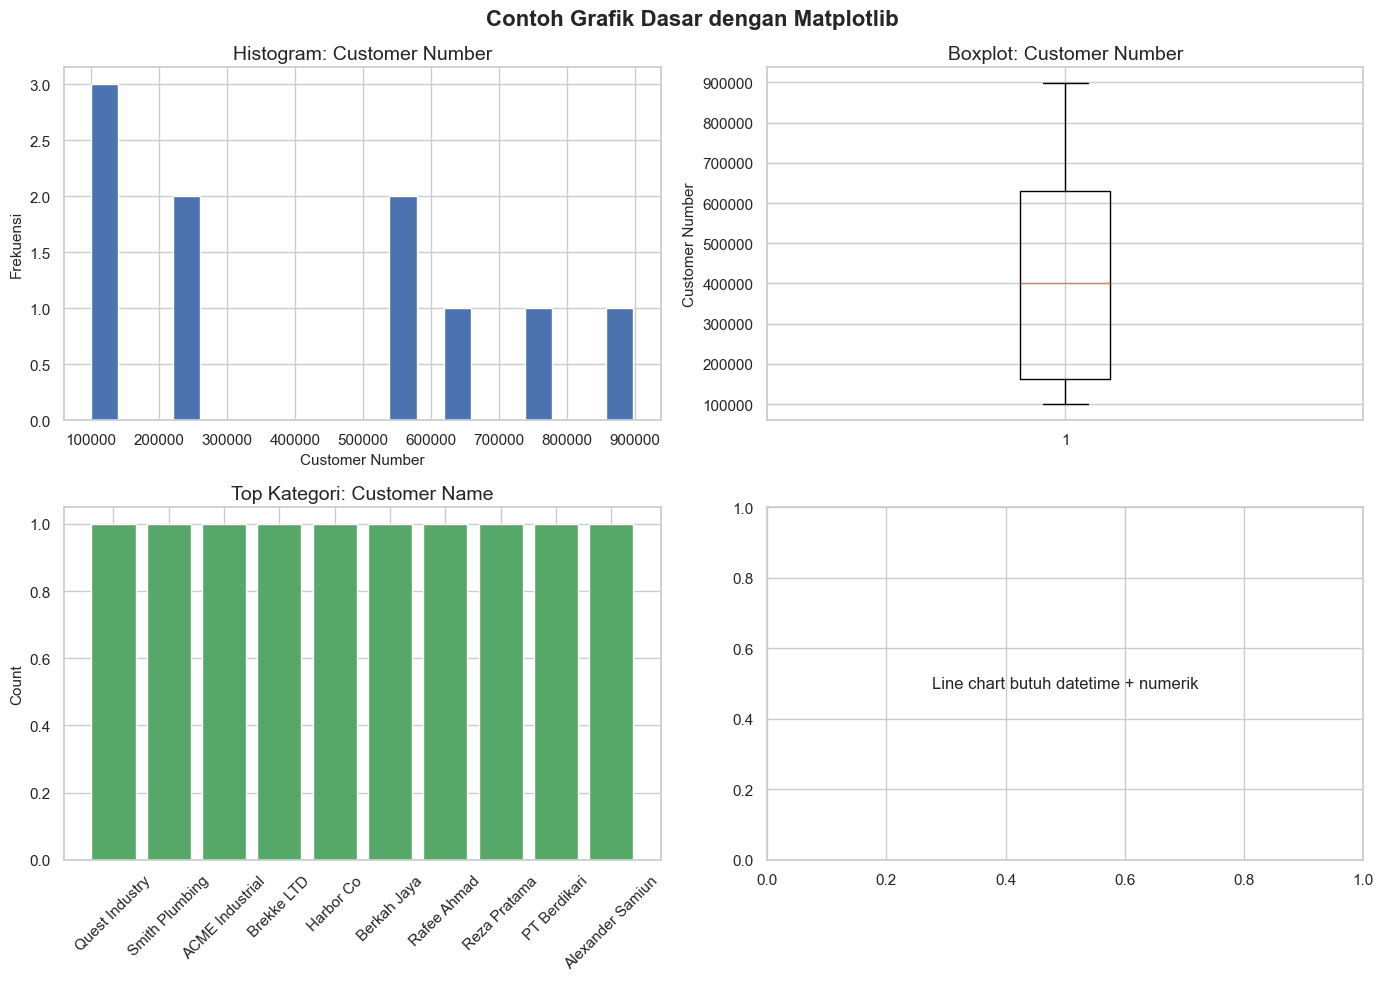

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Contoh Grafik Dasar dengan Matplotlib', fontsize=16, fontweight='bold')

# 1) Histogram
if numeric_cols:
    col = numeric_cols[0]
    axes[0, 0].hist(df[col].dropna(), bins=20, color='#4C72B0', edgecolor='white')
    axes[0, 0].set_title(f'Histogram: {col}')
    axes[0, 0].set_xlabel(col)
    axes[0, 0].set_ylabel('Frekuensi')
else:
    axes[0, 0].text(0.5, 0.5, 'Tidak ada kolom numerik', ha='center', va='center')

# 2) Boxplot
if numeric_cols:
    col = numeric_cols[min(1, len(numeric_cols)-1)]
    axes[0, 1].boxplot(df[col].dropna())
    axes[0, 1].set_title(f'Boxplot: {col}')
    axes[0, 1].set_ylabel(col)
else:
    axes[0, 1].text(0.5, 0.5, 'Tidak ada kolom numerik', ha='center', va='center')

# 3) Bar chart kategori
if category_cols:
    col = category_cols[0]
    top_counts = df[col].astype(str).value_counts().head(10)
    axes[1, 0].bar(top_counts.index, top_counts.values, color='#55A868')
    axes[1, 0].set_title(f'Top Kategori: {col}')
    axes[1, 0].set_ylabel('Count')
    axes[1, 0].tick_params(axis='x', rotation=45)
else:
    axes[1, 0].text(0.5, 0.5, 'Tidak ada kolom kategori', ha='center', va='center')

# 4) Line chart berbasis waktu (jika ada)
if datetime_cols and numeric_cols:
    dt_col = datetime_cols[0]
    num_col = numeric_cols[0]
    ts = df[[dt_col, num_col]].dropna().sort_values(dt_col)
    axes[1, 1].plot(ts[dt_col], ts[num_col], color='#C44E52')
    axes[1, 1].set_title(f'Tren {num_col} terhadap {dt_col}')
    axes[1, 1].set_xlabel(dt_col)
    axes[1, 1].set_ylabel(num_col)
    axes[1, 1].tick_params(axis='x', rotation=45)
else:
    axes[1, 1].text(0.5, 0.5, 'Line chart butuh datetime + numerik', ha='center', va='center')

plt.tight_layout()
plt.show()

### Kustomisasi Matplotlib

Hal penting untuk meningkatkan kualitas grafik:
- Judul informatif.
- Label sumbu dan satuan.
- Grid seperlunya.
- Annotasi pada titik penting.

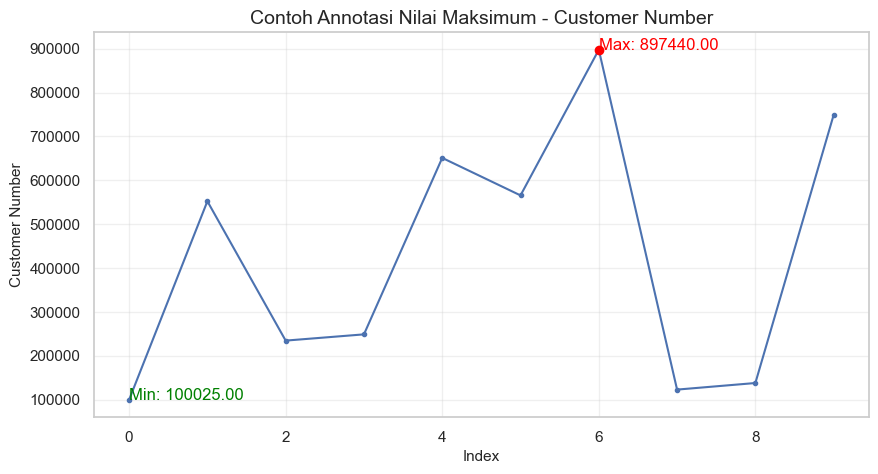

In [5]:
if numeric_cols:
    col = numeric_cols[0]
    series = df[col].dropna()

    plt.figure(figsize=(10, 5))
    plt.plot(series.reset_index(drop=True), marker='o', markersize=3, linewidth=1.5, color='#4C72B0')
    plt.title(f'Contoh Annotasi Nilai Maksimum - {col}')
    plt.xlabel('Index')
    plt.ylabel(col)
    plt.grid(alpha=0.3)

    idx_max = series.idxmax()
    val_max = series.max()
    plt.scatter([idx_max], [val_max], color='red', zorder=5)
    plt.annotate(f'Max: {val_max:.2f}', xy=(idx_max, val_max), xytext=(idx_max, val_max), color='red')
    plt.annotate(f'Min: {series.min():.2f}', xy=(series.idxmin(), series.min()), xytext=(series.idxmin(), series.min()), color='green')

    plt.show()
else:
    print('Tidak ada kolom numerik untuk contoh annotasi.')

## Bagian 3 - Plotly (Interaktif, Cocok untuk Eksplorasi)

Plotly memudahkan eksplorasi karena chart bisa di-zoom, pan, hover detail, dan disimpan sebagai HTML interaktif.

In [6]:
# Plotly histogram
if numeric_cols:
    num_col = numeric_cols[0]
    fig = px.histogram(df, x=num_col, nbins=30, title=f'Plotly Histogram - {num_col}', template='plotly_white')
    fig.show()

# Plotly bar kategori
if category_cols:
    cat_col = category_cols[0]
    tmp = df[cat_col].astype(str).value_counts().head(10).reset_index()
    tmp.columns = [cat_col, 'count']
    fig = px.bar(tmp, x=cat_col, y='count', title=f'Plotly Bar - Top 10 {cat_col}', template='plotly_white')
    fig.update_layout(xaxis_tickangle=-45)
    fig.show()

# Plotly scatter hubungan dua variabel numerik
if len(numeric_cols) >= 2:
    fig = px.scatter(df, x=numeric_cols[0], y=numeric_cols[1], title='Plotly Scatter - Hubungan Dua Variabel Numerik', template='plotly_white')
    fig.show()

In [ ]:
if len(numeric_cols) >= 2:
    col1, col2 = numeric_cols[:2]

    fig = make_subplots(rows=1, cols=2, subplot_titles=[f'Histogram {col1}', f'Boxplot {col2}'])

    fig.add_trace(go.Histogram(x=df[col1], name=col1, marker_color='#4C72B0'), row=1, col=1)
    fig.add_trace(go.Box(y=df[col2], name=col2, marker_color='#C44E52'), row=1, col=2)

    fig.update_layout(title='Kombinasi Plotly Subplots', template='plotly_white', showlegend=False)
    fig.show()
else:
    print('Butuh minimal 2 kolom numerik untuk subplot contoh ini.')

## Bagian 4 - Kapan Pakai Matplotlib vs Plotly?

### Matplotlib
- Kelebihan: ringan, fleksibel, cocok untuk laporan statis (PNG/PDF).
- Cocok untuk: notebook analisis, visual final untuk dokumen.

### Plotly
- Kelebihan: interaktif, mudah eksplorasi detail via hover/zoom/filter.
- Cocok untuk: eksplorasi data, dashboard, presentasi interaktif.

## Bagian 5 - Menghubungkan ke Day-1 / Day-2

Alur yang disarankan saat analisis:

1. **Data cleaning/preprocessing** (day-1/day-2): missing value, tipe data, duplikasi.
2. **EDA numerik dan kategorik**: ringkasan statistik + distribusi.
3. **Visualisasi inti**: tren, komparasi, relasi, outlier.
4. **Insight**: tulis 2-3 temuan utama berbasis grafik.
5. **Actionable recommendation**: langkah bisnis/analitis berikutnya.

In [ ]:
df_clean = df.copy()

# Contoh preprocessing singkat
df_clean = df_clean.drop_duplicates()

# Isi missing numerik dengan median (hanya contoh, sesuaikan dengan kasus nyata)
for c in df_clean.select_dtypes(include='number').columns:
    df_clean[c] = df_clean[c].fillna(df_clean[c].median())

print('Ukuran data setelah cleaning:', df_clean.shape)

# Visual cepat setelah cleaning
num_cols_clean = df_clean.select_dtypes(include='number').columns.tolist()
if num_cols_clean:
    target_col = num_cols_clean[0]

    plt.figure(figsize=(8, 4))
    sns.histplot(df_clean[target_col], kde=True, color='#55A868')
    plt.title(f'Distribusi {target_col} Setelah Cleaning')
    plt.xlabel(target_col)
    plt.show()

    fig = px.box(df_clean, y=target_col, title=f'Boxplot Interaktif {target_col} Setelah Cleaning', template='plotly_white')
    fig.show()

## Latihan Mandiri

Silakan kerjakan latihan berikut:

1. Pilih 1 pertanyaan analisis dari dataset yang digunakan.
2. Buat minimal 3 visual: 1 tren, 1 perbandingan kategori, 1 distribusi.
3. Gunakan **Matplotlib** untuk 2 visual dan **Plotly** untuk 1 visual.
4. Tulis insight dari setiap visual (1-2 kalimat).
5. Tambahkan 1 rekomendasi berbasis data.

In [ ]:
# Template latihan (isi sesuai kebutuhan)

# 1) Pertanyaan analisis:
# ...

# 2) Visual 1 (Matplotlib):
# ...

# 3) Visual 2 (Matplotlib):
# ...

# 4) Visual 3 (Plotly):
# ...

# 5) Insight & rekomendasi:
# ...

## Penutup

Dengan menguasai Matplotlib dan Plotly, peserta bisa berpindah dari sekadar melihat angka ke **menceritakan data dengan visual**. Ini akan sangat membantu saat mengerjakan EDA, evaluasi preprocessing, dan komunikasi insight di tahap modeling berikutnya.